In [1]:
import numpy as np
def km_to_au(km):
    return km / 1.496e+8

def au_to_km(vector):
    AU_KM = 1.496e8
    return np.array(vector) * AU_KM

# Orbital elements (J2000 ecliptic)
semi_major_axis = au_to_km(1.64966575)         
eccentricity = 0.3905426           
inclination = np.radians(10.68657)            
raan = np.radians(214.44311)       
arg_perihelion = np.radians(359.94542)         
mean_anomaly = np.radians(32.28475405)         

print("Orbital elements:")
print(f"  a = {semi_major_axis} km")
print(f"  e = {eccentricity}")
print(f"  i  = {inclination}") 
print(f"  Omega = {raan}")
print(f"  omega = {arg_perihelion}")
print(f"  M = {mean_anomaly}")

Orbital elements:
  a = 246789996.20000002 km
  e = 0.3905426
  i  = 0.1865158322448504
  Omega = 3.7427383277163773
  omega = 6.282232706473848
  M = 0.5634752563690739


In [14]:
import numpy as np

eccentricity = 0.39065638329
perihelion_distance = 1.00537190434
time_perihelion = 60440.597032

raan = 3.7424401058
arg_perihelion = 6.2824862006
inclination = 0.18655891068

current_time = 60490.0   

# Compute semi-major axis
semi_major_axis = perihelion_distance / (1 - eccentricity)

# Sun gravitational parameter (AU^3/day^2)
mu_sun = 0.01720209895**2 

# Mean motion
mean_motion = np.sqrt(mu_sun / semi_major_axis**3) 

# Mean anomaly
mean_anomaly = mean_motion * (current_time - time_perihelion)
mean_anomaly = mean_anomaly % (2 * np.pi)

print("Mean anomaly:", mean_anomaly)
# Convert to km
AU_KM = 1.496e8
semi_major_axis_km = semi_major_axis * AU_KM

print("Semi-major axis (AU):", semi_major_axis)
print("Semi-major axis (km):", semi_major_axis_km)

Mean anomaly: 0.40099389871271346
Semi-major axis (AU): 1.6499260462729664
Semi-major axis (km): 246828936.52243575


In [15]:
import numpy as np
from astropy.coordinates import get_body_barycentric_posvel
from astropy.time import Time
import astropy.units as u


AU_TO_KM = 1.496e8
MU_SUN = 1.32712440018e11          # km^3/s^2
OBLIQUITY = np.radians(23.43929111)


def km_to_au(x):
    return x / AU_TO_KM

def au_to_km(vec):
    return np.array(vec) * AU_TO_KM



def Rz(theta):
    return np.array([
        [ np.cos(theta), -np.sin(theta), 0],
        [ np.sin(theta),  np.cos(theta), 0],
        [ 0,              0,             1]
    ])

def Rx(theta):
    return np.array([
        [1, 0,              0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta),  np.cos(theta)]
    ])


def perifocal_position(a, e, f):
    r = a * (1 - e**2) / (1 + e*np.cos(f))
    return np.array([r*np.cos(f), r*np.sin(f), 0.0])

def perifocal_velocity(a, e, f, mu):
    scale = np.sqrt(mu / (a * (1 - e**2)))
    return scale * np.array([
        -np.sin(f),
         e + np.cos(f),
         0.0
    ])


def perifocal_to_inertial(r_pf, v_pf, raan, inc, argp):
    transform = Rz(raan) @ Rx(inc) @ Rz(argp)
    return transform @ r_pf, transform @ v_pf


def apply_obliquity(r, v):
    rot = Rx(OBLIQUITY)
    return rot @ r, rot @ v


def solve_kepler(M, e, tol=1e-10):
    E = M
    while True:
        f = E - e*np.sin(E) - M
        f_prime = 1 - e*np.cos(E)
        E_new = E - f / f_prime
        if abs(E_new - E) < tol:
            return E_new
        E = E_new


def mean_to_true_anomaly(M, e):
    E = solve_kepler(M, e)
    return 2*np.arctan2(
        np.sqrt(1+e)*np.sin(E/2),
        np.sqrt(1-e)*np.cos(E/2)
    )


epoch = Time("2024-06-29 00:00:00", scale="tdb")

earth_pos_bary, earth_vel_bary = get_body_barycentric_posvel("earth", epoch)
sun_pos_bary, sun_vel_bary = get_body_barycentric_posvel("sun", epoch)

earth_position = (earth_pos_bary.xyz - sun_pos_bary.xyz).to(u.km).value
earth_velocity = (earth_vel_bary.xyz - sun_vel_bary.xyz).to(u.km/u.s).value

print("Earth position (km):", earth_position)
print("Earth velocity (km/s):", earth_velocity)


true_anomaly = mean_to_true_anomaly(mean_anomaly, eccentricity)

r_pf = perifocal_position(semi_major_axis_km, eccentricity, true_anomaly)
v_pf = perifocal_velocity(semi_major_axis_km, eccentricity, true_anomaly, MU_SUN)

asteroid_position, asteroid_velocity = perifocal_to_inertial(
    r_pf, v_pf,
    raan, inclination, arg_perihelion
)

asteroid_position, asteroid_velocity = apply_obliquity(
    asteroid_position, asteroid_velocity
)

print("True anomaly (deg):", np.degrees(true_anomaly))
print("Asteroid position (km):", asteroid_position)
print("Asteroid velocity (km/s):", asteroid_velocity)

earth_state0 = np.concatenate((earth_position, earth_velocity))
asteroid_state0 = np.concatenate((asteroid_position, asteroid_velocity))

# =========================
# TIME SETUP
# =========================
start_time = Time("2024-06-29", scale="tdb")
end_time = Time("2041-05-25", scale="tdb")
target_time = Time("2041-04-24", scale="tdb")

# convert to seconds
end_time_sec = (end_time - start_time).to_value('sec')
target_seconds = (target_time - start_time).to_value('sec')

# initial time
t0 = 0.0

Earth position (km): [ 1.96344655e+07 -1.38368950e+08 -5.99811486e+07]
Earth velocity (km/s): [29.05675601  3.415037    1.47896529]
True anomaly (deg): 52.54759525228413
Asteroid position (km): [-1.03564528e+07 -1.62974291e+08 -4.35486574e+07]
Asteroid velocity (km/s): [ 30.4638399  -10.21358397   0.66066116]


In [12]:
from scipy.integrate import solve_ivp
import numpy as np

# =========================
# DYNAMICS
# =========================
def two_body_ode(t, state):
    r = state[:3]
    v = state[3:]
    r_norm = np.linalg.norm(r)

    a = -MU_SUN * r / r_norm**3

    return np.concatenate((v, a))


# =========================
# TIME SETUP
# =========================
t_span = (0, end_time_sec)

# dense time grid so we hit target accurately
t_eval = np.linspace(0, end_time_sec, 20000)


# =========================
# PROPAGATE EARTH
# =========================
sol_E = solve_ivp(
    two_body_ode,
    t_span,
    earth_state0,
    method='DOP853',
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

# =========================
# PROPAGATE ASTEROID
# =========================
sol_A = solve_ivp(
    two_body_ode,
    t_span,
    asteroid_state0,
    method='DOP853',
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)


# =========================
# EXTRACT TRAJECTORIES
# =========================
earth_traj = sol_E.y[:3].T
ast_traj = sol_A.y[:3].T
times = sol_E.t


# =========================
# FIND CLOSEST TO TARGET DATE
# =========================
idx = np.argmin(np.abs(times - target_seconds))

rE = earth_traj[idx]
rA = ast_traj[idx]

distance = np.linalg.norm(rA - rE)


# =========================
# OUTPUT
# =========================
print("\n--- April 24, 2041 ---")
print("Distance (km):", distance)


--- April 24, 2041 ---
Distance (km): 923765.9474440258


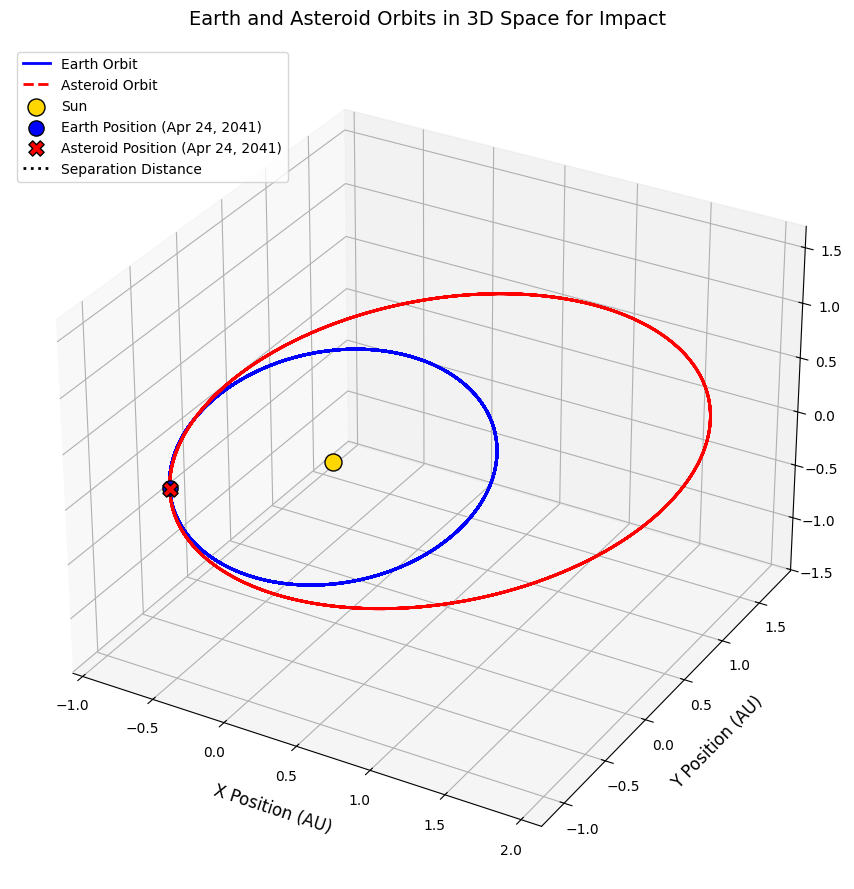

In [13]:
import numpy as np
import matplotlib.pyplot as plt

earth_positions = earth_traj
asteroid_positions = ast_traj

earth_target = earth_traj[idx]
asteroid_target = ast_traj[idx]

AU_KM = 1.496e8

earth_AU = earth_positions / AU_KM
asteroid_AU = asteroid_positions / AU_KM

earth_target_AU = earth_target / AU_KM
asteroid_target_AU = asteroid_target / AU_KM

#plot
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')

# Orbits
ax.plot(
    earth_AU[:, 0], earth_AU[:, 1], earth_AU[:, 2],
    color='blue', linewidth=2, label='Earth Orbit'
)

ax.plot(
    asteroid_AU[:, 0], asteroid_AU[:, 1], asteroid_AU[:, 2],
    color='red', linewidth=2, linestyle='--', label='Asteroid Orbit'
)

# Sun
ax.scatter(
    0, 0, 0,
    color='gold', s=150, edgecolors='black',
    label='Sun'
)

# Target points
ax.scatter(
    earth_target_AU[0], earth_target_AU[1], earth_target_AU[2],
    color='blue', s=120, marker='o', edgecolors='black',
    label='Earth Position (Apr 24, 2041)'
)

ax.scatter(
    asteroid_target_AU[0], asteroid_target_AU[1], asteroid_target_AU[2],
    color='red', s=120, marker='X', edgecolors='black',
    label='Asteroid Position (Apr 24, 2041)'
)

# Separation line
ax.plot(
    [earth_target_AU[0], asteroid_target_AU[0]],
    [earth_target_AU[1], asteroid_target_AU[1]],
    [earth_target_AU[2], asteroid_target_AU[2]],
    color='black', linestyle=':', linewidth=2,
    label='Separation Distance'
)

# Labels + Title
ax.set_xlabel('X Position (AU)', fontsize=12, labelpad=10)
ax.set_ylabel('Y Position (AU)', fontsize=12, labelpad=10)
ax.set_zlabel('Z Position (AU)', fontsize=12, labelpad=10)

ax.set_title(
    'Earth and Asteroid Orbits in 3D Space for Impact',
    fontsize=14, pad=15
)

all_data = np.vstack((earth_AU, asteroid_AU))

max_range = np.max([
    all_data[:, 0].max() - all_data[:, 0].min(),
    all_data[:, 1].max() - all_data[:, 1].min(),
    all_data[:, 2].max() - all_data[:, 2].min()
]) / 2.0

mid_x = 0.5 * (all_data[:, 0].max() + all_data[:, 0].min())
mid_y = 0.5 * (all_data[:, 1].max() + all_data[:, 1].min())
mid_z = 0.5 * (all_data[:, 2].max() + all_data[:, 2].min())

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

# Grid
ax.grid(True, linestyle='--', alpha=0.5)

# Pane styling (same look)
ax.xaxis.pane.fill = True
ax.yaxis.pane.fill = True
ax.zaxis.pane.fill = True

# Legend
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
import numpy as np
from tqdm import tqdm

mean_f = np.array([
    3.9065638329e-01, 1.0053719043e+00, 6.0440597032e+04,
    3.7424401058e+00, 6.2824862006e+00, 1.8655891068e-01
])

cov_f = np.array([
 [ 1.5981923825e-07,  1.4679012487e-08,  5.0334325147e-06, -8.1399217592e-08,  1.1172143036e-07,  3.7238260898e-08],
 [ 1.4679012487e-08,  1.3824336777e-09,  4.7067695794e-07, -7.5646281343e-09,  1.0528122713e-08,  3.3981522211e-09],
 [ 5.0334325147e-06,  4.7067695794e-07,  1.6070145148e-04, -2.5857588561e-06,  3.5870179594e-06,  1.1666904492e-06],
 [-8.1399217592e-08, -7.5646281343e-09, -2.5857588561e-06,  4.1892770273e-08, -5.7800111332e-08, -1.8879572864e-08],
 [ 1.1172143036e-07,  1.0528122713e-08,  3.5870179594e-06, -5.7800111332e-08,  8.0446076998e-08,  2.5815369920e-08],
 [ 3.7238260898e-08,  3.3981522211e-09,  1.1666904492e-06, -1.8879572864e-08,  2.5815369920e-08,  8.6997569187e-09]
])

print("Mean elements:")
print(mean_f)

print("\nCovariance matrix:")
print(cov_f)


def elements_to_state(elts):

    e, q, tp, Omega, omega, inc = elts

    AU_KM = 1.496e8
    mu = 1.32712440018e11

    # semi-major axis
    a_AU = q / (1 - e)
    a_km = a_AU * AU_KM

    # mean motion
    n = np.sqrt(mu / a_km**3)

    # time conversion
    t_now = start_time.tdb.mjd * 86400
    t_peri = tp * 86400

    # mean anomaly
    M = n * (t_now - t_peri)
    M = M % (2*np.pi)

    # true anomaly
    f = mean_to_true_anomaly(M, e)


    # perifocal
    r_pf = perifocal_position(a_km, e, f)
    v_pf = perifocal_velocity(a_km, e, f, mu)

    # inertial rotation
    r, v = perifocal_to_inertial(r_pf, v_pf, Omega, inc, omega)

    # obliquity rotation
    eps = np.radians(23.43929111)

    R = np.array([
        [1, 0, 0],
        [0, np.cos(eps), -np.sin(eps)],
        [0, np.sin(eps),  np.cos(eps)]
    ])

    r = R @ r
    v = R @ v

    return r, v


def propagate_sample(xE0, xA0):

    # =========================
    # DYNAMICS
    # =========================
    def two_body_ode(t, state):
        r = state[:3]
        v = state[3:]
        r_norm = np.linalg.norm(r)
        a = -MU_SUN * r / r_norm**3
        return np.concatenate((v, a))

    # =========================
    # TIME SETUP
    # =========================
    t_span = (0, end_time_sec)

    t_eval = np.linspace(target_seconds - 5*86400,
                         target_seconds + 5*86400,
                         3000)

    # =========================
    # PROPAGATE EARTH
    # =========================
    sol_E = solve_ivp(
        two_body_ode,
        t_span,
        xE0,
        method='DOP853',
        t_eval=t_eval,
        rtol=1e-10,
        atol=1e-12
    )

    # =========================
    # PROPAGATE ASTEROID
    # =========================
    sol_A = solve_ivp(
        two_body_ode,
        t_span,
        xA0,
        method='DOP853',
        t_eval=t_eval,
        rtol=1e-10,
        atol=1e-12
    )

    # =========================
    # EXTRACT POSITIONS
    # =========================
    rE_hist = sol_E.y[:3].T
    rA_hist = sol_A.y[:3].T
    times = sol_E.t

    # =========================
    # CLOSEST APPROACH
    # =========================
    idx = np.argmin(np.abs(times - target_seconds))

    rE = rE_hist[idx]
    rA = rA_hist[idx]

    d = np.linalg.norm(rA - rE)

    # =========================
    # IMPACT CHECK
    # =========================
    if d <= 6378:
        return 0.0, True

    return d, False


def run_monte_carlo(n_trials):

    samples = np.random.multivariate_normal(mean_f, cov_f, size=n_trials)

    distances = []
    impacts = []

    print("\nRunning Monte Carlo...")

    for i in tqdm(range(n_trials)):

        r_s, v_s = elements_to_state(samples[i])
        xA0 = np.concatenate((r_s, v_s))

        d, hit = propagate_sample(earth_state0, xA0)

        distances.append(d)
        impacts.append(hit)

    return np.array(distances), np.array(impacts)


#Simulation
num_trials = 500

distances, impacts = run_monte_carlo(num_trials)

print("Impact probability:", np.mean(impacts))
print("Minimum distance (km):", np.min(distances))

Mean elements:
[3.90656383e-01 1.00537190e+00 6.04405970e+04 3.74244011e+00
 6.28248620e+00 1.86558911e-01]

Covariance matrix:
[[ 1.59819238e-07  1.46790125e-08  5.03343251e-06 -8.13992176e-08
   1.11721430e-07  3.72382609e-08]
 [ 1.46790125e-08  1.38243368e-09  4.70676958e-07 -7.56462813e-09
   1.05281227e-08  3.39815222e-09]
 [ 5.03343251e-06  4.70676958e-07  1.60701451e-04 -2.58575886e-06
   3.58701796e-06  1.16669045e-06]
 [-8.13992176e-08 -7.56462813e-09 -2.58575886e-06  4.18927703e-08
  -5.78001113e-08 -1.88795729e-08]
 [ 1.11721430e-07  1.05281227e-08  3.58701796e-06 -5.78001113e-08
   8.04460770e-08  2.58153699e-08]
 [ 3.72382609e-08  3.39815222e-09  1.16669045e-06 -1.88795729e-08
   2.58153699e-08  8.69975692e-09]]

Running Monte Carlo...


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [01:21<00:00,  6.13it/s]

Impact probability: 0.0
Minimum distance (km): 462117.29774019384
